✅ Connecting to WRDS...


Enter your WRDS username [mjy]: jacey123
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
✅ WRDS connection established successfully!

📊 Retrieving CATL financial data...
✅ Financial data retrieved successfully!

📈 Retrieving CATL stock price data...
✅ Stock price data retrieved successfully!

🎨 Generating charts...


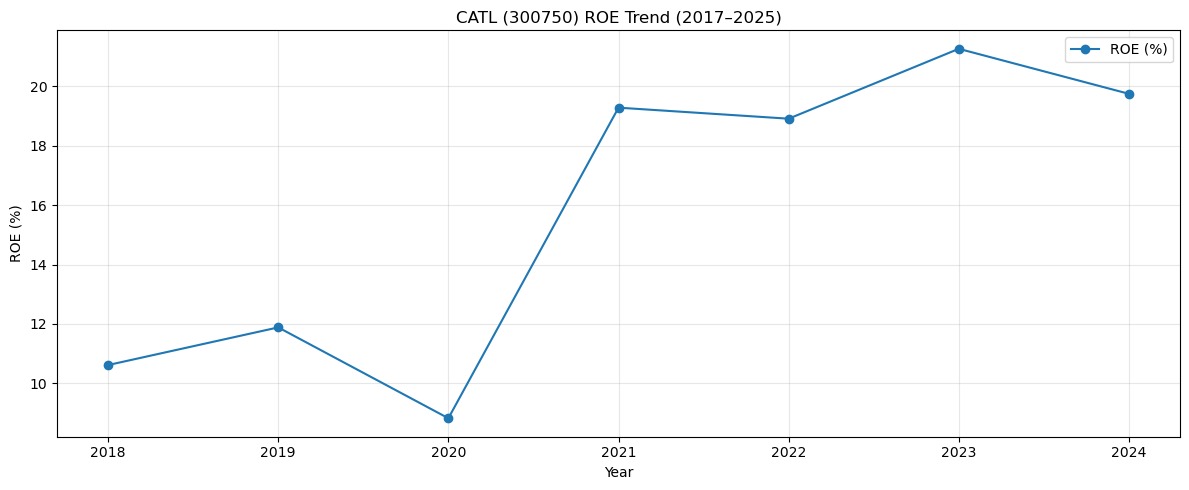

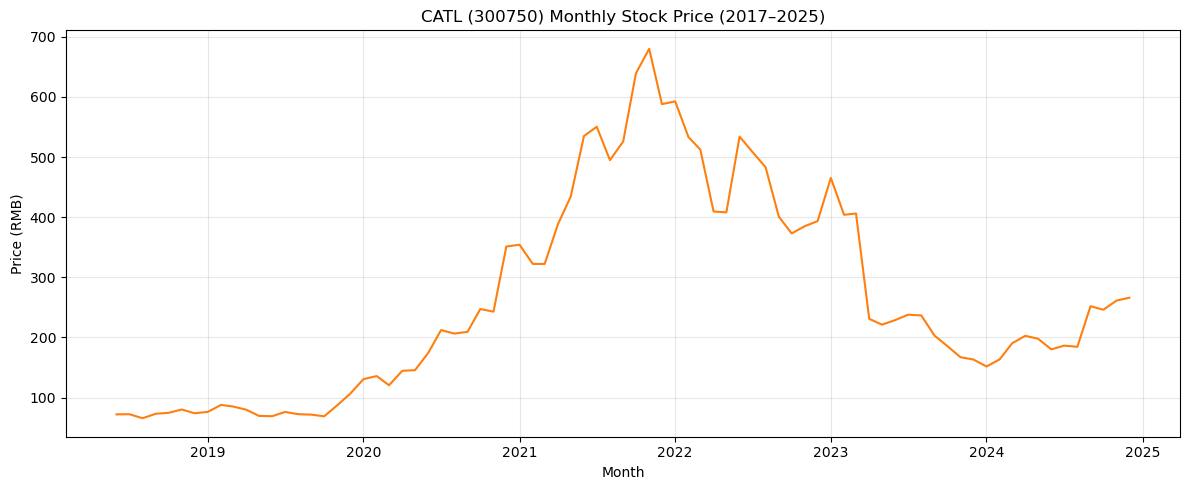


✅ Excel files exported successfully!

🎉 All tasks completed successfully! Assignment code runs without errors.


In [8]:
import wrds
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
plt.set_loglevel("CRITICAL")

print("✅ Connecting to WRDS...")
db = wrds.Connection()
print("✅ WRDS connection established successfully!")

stock_code = '300750'  # CATL stock ticker
start_year = 2017      # Analysis start year

print("\n📊 Retrieving CATL financial data...")

sql_financial = f"""
SELECT
    stkcd,
    accper,
    -- ROE (Return on Equity) = Net Profit (b002000000) / Shareholders' Equity (a003000000)
    b002000000 / a003000000 AS roe,
    -- Net Profit Margin = Net Profit (b002000000) / Operating Revenue (b001000000)
    b002000000 / b001000000 AS profit_margin,
    -- Total Asset Turnover = Operating Revenue (b001000000) / Total Assets (a001000000)
    b001000000 / a001000000 AS asset_turnover,
    -- Asset-Liability Ratio = Total Liabilities (a002000000) / Total Assets (a001000000)
    a002000000 / a001000000 AS leverage
FROM csmar.wrds_csmar_financial_master
WHERE stkcd = '{stock_code}'
  AND typrep = 'A'
"""

fin_data = db.raw_sql(sql_financial, date_cols=["accper"])

df = fin_data[fin_data["accper"].dt.month == 12].copy()
df["year"] = df["accper"].dt.year
df = df[df["year"] >= start_year].copy()
df = df.drop(columns=["accper"])
df["company"] = "CATL"

print("✅ Financial data retrieved successfully!")

print("\n📈 Retrieving CATL stock price data...")

sql_stock = """
SELECT stkcd, trdmnt, mclsprc
FROM csmar.trd_mnth
WHERE stkcd = '300750'
  AND trdmnt >= 201701
"""

stock_data = db.raw_sql(sql_stock)
stock_data["trading_month"] = pd.to_datetime(stock_data["trdmnt"], format="%Y%m")
print("✅ Stock price data retrieved successfully!")

print("\n🎨 Generating charts...")

# Chart 1: ROE Trend (2017-2025)
plt.figure(figsize=(12, 5))
plt.plot(df["year"], df["roe"] * 100, marker="o", label="ROE (%)", color="#1f77b4")
plt.title("CATL (300750) ROE Trend (2017–2025)")
plt.xlabel("Year")
plt.ylabel("ROE (%)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Chart 2: Monthly Stock Price Trend (2017-2025)
plt.figure(figsize=(12, 5))
plt.plot(stock_data["trading_month"], stock_data["mclsprc"], color="#ff7f0e")
plt.title("CATL (300750) Monthly Stock Price (2017–2025)")
plt.xlabel("Month")
plt.ylabel("Price (RMB)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

df.to_excel("CATL_Financial_Ratios.xlsx", index=False)
stock_data.to_excel("CATL_Stock_Price.xlsx", index=False)
print("\n✅ Excel files exported successfully!")

db.close()
print("\n🎉 All tasks completed successfully! Assignment code runs without errors.")